# Syn Bank — Share of Wallet Intelligence Engine

**Team The Independent Variable** · Daniel Mataranyika, Herton Mabongue
Standard Bank × Data School Hackathon 2026

---

This notebook is the reproducible record of the analysis: ingestion, transformation,
modelling and visualisation, end to end.

**The question.** Syn Bank can see every transaction that flows through Syn Bank. It
cannot see the transactions that flow through its competitors. So *"what fraction of
this client's banking activity do we hold?"* cannot be read off the internal data —
it has to be estimated from outside.

**What we found first.** Our own initial model got this wrong in a way worth showing,
because the failure is invisible to the obvious sanity checks. Section 3 reproduces
it and measures the damage. Sections 4–6 build the replacement.

**How to run.** Place the three supplied CSVs in `data/raw/`, install
`requirements.txt`, then run top to bottom. No API key is needed — the GenAI section
falls back to cached responses.

## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Palette: slots 1-3 of the validated categorical set. Blue carries "what Syn Bank
# actually holds", orange "what it does not". Aqua is only used where a value is
# also directly labelled, because it sits below 3:1 contrast on white.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e6e3"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 9.5,
    "legend.frameon": False,
})

def zar(v, _=None):
    v = float(v)
    if abs(v) >= 1e12: return f"R{v/1e12:.1f}T"
    if abs(v) >= 1e9:  return f"R{v/1e9:.0f}B"
    if abs(v) >= 1e6:  return f"R{v/1e6:.0f}M"
    return f"R{v:,.0f}"

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| root", ROOT.name)

python 3.14.6 | pandas 3.0.5 | root the_independent_variable-standard-bank-hackathon-2026


## 2. Data ingestion

Two independent bodies of evidence. Keeping them separate is the whole point of the
model, so they are loaded separately and only joined in section 6.

In [2]:
from models.wallet_engine import load_raw_tables, load_benchmarks, load_external_financials

benchmarks = load_benchmarks()
transactional, cross_border, trade = load_raw_tables()

print("INTERNAL (what Syn Bank observed)")
for name, df in [("transactional_banking", transactional),
                 ("cross_border_payments", cross_border),
                 ("trade_finance", trade)]:
    print(f"  {name:<24} {len(df):>9,} rows   "
          f"{df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}   "
          f"{df['entity_id'].nunique()} entities")

INTERNAL (what Syn Bank observed)
  transactional_banking    2,802,875 rows   2023-07-01 to 2026-06-30   20 entities
  cross_border_payments      241,117 rows   2023-07-01 to 2026-06-30   20 entities
  trade_finance               20,303 rows   2023-07-01 to 2026-06-30   20 entities


In [3]:
external = load_external_financials(benchmarks)

print("EXTERNAL (published FY2025 financial statements)")
print(f"  {len(external)} companies, every figure cited in data/external/company_financials.csv\n")

external[["client_id", "client_name", "sector", "revenue_zar_m",
          "foreign_revenue_share", "sa_attribution_share", "source_quality"]].head(8)

EXTERNAL (published FY2025 financial statements)
  20 companies, every figure cited in data/external/company_financials.csv



,client_id,client_name,sector,revenue_zar_m,foreign_revenue_share,sa_attribution_share,source_quality
0,E01,BHP Group,mining,917244,0.98,0.05,reported
1,E02,Glencore,mining,4128492,0.99,0.03,reported
2,E03,Anglo American,mining,484548,0.95,0.25,reported
3,E04,AngloGold Ashanti,mining,177012,0.92,0.15,reported
4,E05,Gold Fields,mining,156468,0.90,0.15,reported
5,E06,Valterra Platinum,mining,116400,0.75,0.95,reported
6,E07,OUTsurance Group,insurance,35994,0.15,0.90,reported
7,E08,Sanlam,insurance,292015,0.30,0.75,reported


### 2.1 Data quality

Three things worth checking before trusting any of it: that the two sides cover the
same clients, that nothing is silently missing, and how much of the external data is
reported rather than imputed.

In [4]:
internal_ids = set(transactional["entity_id"]) | set(cross_border["entity_id"]) | set(trade["entity_id"])
external_ids = set(external["client_id"])

print(f"clients in internal data : {len(internal_ids)}")
print(f"clients in external data : {len(external_ids)}")
print(f"in both                  : {len(internal_ids & external_ids)}")
print(f"internal only            : {sorted(internal_ids - external_ids) or 'none'}")
print(f"external only            : {sorted(external_ids - internal_ids) or 'none'}")

print("\nnulls in internal tables:")
for name, df in [("transactional", transactional), ("cross_border", cross_border), ("trade", trade)]:
    n = int(df.isna().sum().sum())
    print(f"  {name:<14} {n:,}")

print("\nexternal input provenance:")
print(f"  cost of sales reported  : {(~external['cogs_imputed']).sum()}/{len(external)}")
print(f"  inventory reported      : {(~external['inventory_imputed']).sum()}/{len(external)}")
print(external["source_quality"].value_counts().to_string())

clients in internal data : 20
clients in external data : 20
in both                  : 20
internal only            : none
external only            : none

nulls in internal tables:


  transactional  0
  cross_border   3,665
  trade          0

external input provenance:
  cost of sales reported  : 3/20
  inventory reported      : 1/20
source_quality
reported    18
derived      2


> **Note.** The brief describes a portfolio of 50 JSE-listed clients; the supplied
> data contains 20. We modelled what was supplied rather than extrapolating, and
> flag it as a limitation rather than quietly scaling up.

## 3. The mistake worth showing

Our first model sized the wallet from internal flow and then estimated the captured
share as a fraction of it:

```
wallet    = internal_flow x benchmark_ratio
captured  = wallet x capture_ratio          # capture_ratio from transaction counts, channels
share     = captured / wallet
```

Substituting gives `share = capture_ratio`. **The wallet term cancels.** Share of
wallet was mathematically identical to the assumed capture rate and could not depend
on the data at all.

Every obvious check passes: shares are between 0 and 1, they vary a little between
clients, the ranking looks plausible. Reproducing it below shows what the checks miss.

In [5]:
# Reproduction of the original capture-ratio heuristic.
def old_capture_ratio(row):
    r = (0.10
         + 0.05 * min(row["transaction_count"] / 4500.0, 1.0)
         + 0.04 * min(row["channel_count"] / 4.0, 1.0)
         + 0.03 * row["inbound_ratio"])
    return float(np.clip(r, 0.08, 0.32))

old = (transactional.groupby("entity_id")
       .agg(client_name=("entity_name", "first"),
            flow=("amount_zar", "sum"),
            transaction_count=("amount_zar", "size"),
            channel_count=("channel", "nunique"),
            inbound_ratio=("direction", lambda s: float((s == "inbound").mean())))
       .reset_index())

old["wallet"]   = old["flow"] * 0.0018          # flow x benchmark ratio
old["capture"]  = old.apply(old_capture_ratio, axis=1)
old["captured"] = old["wallet"] * old["capture"]
old["share"]    = old["captured"] / old["wallet"]

print(f"wallet sizes span {old['wallet'].max() / old['wallet'].min():,.0f}x across the portfolio")
print(f"yet share spans only {(old['share'].max() - old['share'].min()) * 100:.1f} percentage points")
print(f"  min {old['share'].min()*100:.1f}%   max {old['share'].max()*100:.1f}%   std {old['share'].std():.4f}")
print(f"\nshare == capture_ratio exactly: {np.allclose(old['share'], old['capture'])}")

wallet sizes span 2,757x across the portfolio
yet share spans only 4.4 percentage points
  min 16.1%   max 20.6%   std 0.0131

share == capture_ratio exactly: True


`share == capture_ratio` to floating-point equality. The data never enters the answer.

This is now guarded by a regression test —
`tests/test_wallet_engine.py::test_share_varies_across_clients` — so it cannot come back.

## 4. Top-down: sizing the addressable flow

The replacement estimates each client's addressable banking flow from **published
financial statements**, which Syn Bank's internal data cannot influence.

| Pillar | Statement signal | Why |
|---|---|---|
| Transactional | Revenue | Collections, supplier payments, payroll and treasury all cross the account; both sides of the working-capital cycle pass through, so annual flow exceeds annual revenue. |
| FX / cross-border | Revenue x foreign revenue share | Exporters repatriate receipts, importers settle abroad, intercompany treasury adds a leg. |
| Trade finance | Cost of sales + inventory | Documentary instruments are raised against the physical goods cycle. Only a minority of trade settles under an instrument, so multiples sit well below 1. |

Each is scaled by an **SA-attribution share** — Syn Bank is a South African bank, so
BHP's worldwide revenue is not addressable to it. That is the most judgmental input in
the model and lives in one reviewable column.

In [6]:
from models.wallet_engine import estimate_addressable_flow

addressable = estimate_addressable_flow(external, benchmarks)

view = addressable[["client_name", "sector", "addressable_transactional_base",
                    "addressable_fx_base", "addressable_trade_finance_base",
                    "addressable_base"]].copy()
view.columns = ["client", "sector", "transactional", "fx", "trade finance", "total"]
for c in ["transactional", "fx", "trade finance", "total"]:
    view[c] = view[c].map(zar)
view.sort_values("client").head(10)

,client,sector,transactional,fx,trade finance,total
2,Anglo American,mining,R206B,R184B,R20B,R410B
3,AngloGold Ashanti,mining,R45B,R39B,R4B,R89B
18,Aspen Pharmacare,industrials_pharma,R19B,R10B,R1B,R31B
0,BHP Group,mining,R78B,R72B,R7B,R157B
9,Bid Corporation,consumer,R123B,R49B,R8B,R180B
11,Clicks Group,consumer,R122B,R1B,R8B,R131B
1,Glencore,mining,R211B,R196B,R20B,R427B
4,Gold Fields,mining,R40B,R34B,R4B,R78B
15,MTN Group,telecoms,R125B,R49B,R4B,R178B
12,NEPI Rockcastle,real_estate,R375M,R150M,R4M,R529M


## 5. Bottom-up: measuring what Syn Bank actually captured

A straight sum over the **trailing 12 months**, so it is comparable to an annual
financial-statement figure. No assumption enters this side — that is what makes the
sensitivity analysis in section 9 meaningful.

In [7]:
from models.wallet_engine import measure_captured_flow

captured = measure_captured_flow(transactional, cross_border, trade)

print(f"captured flow, trailing 12 months: {zar(captured['captured_total'].sum())}\n")
cv = captured[["client_id", "captured_transactional", "captured_fx",
               "captured_trade_finance", "captured_total"]].copy()
for c in cv.columns[1:]:
    cv[c] = cv[c].map(zar)
cv.head(10)

captured flow, trailing 12 months: R192B



,client_id,captured_transactional,captured_fx,captured_trade_finance,captured_total
0,E01,R17B,R2B,R1B,R20B
1,E02,R4B,R2B,R1B,R8B
2,E03,R8B,R999M,R634M,R9B
3,E04,R2B,R852M,R518M,R3B
4,E05,R2B,R909M,R696M,R3B
5,E06,R52M,R203M,R115M,R370M
6,E07,R345M,R1B,R81M,R2B
7,E08,R19B,R3B,R152M,R22B
8,E09,R11B,R3B,R2B,R16B
9,E10,R13B,R6B,R2B,R21B


## 6. Combining the two sides

In [8]:
from models.wallet_engine import compute_share_of_wallet

wallet = compute_share_of_wallet(addressable, captured, benchmarks)

total_addr = wallet["addressable_base"].sum()
total_capt = wallet["captured_total"].sum()

print(f"addressable flow      {zar(total_addr)}")
print(f"captured by Syn Bank  {zar(total_capt)}")
print(f"portfolio share       {total_capt / total_addr * 100:.1f}%")
print(f"uncaptured gap        {zar(wallet['gap'].sum())}")
print(f"annual fee opportunity{zar(wallet['revenue_opportunity'].sum())}")
print(f"\nshare spread: {wallet['syn_share'].min()*100:.1f}% to {wallet['syn_share'].max()*100:.1f}%"
      f"  (std {wallet['syn_share'].std():.3f})")
print(f"clients where captured exceeds the estimate: {int(wallet['share_exceeds_estimate'].sum())}")

addressable flow      R4.3T
captured by Syn Bank  R192B
portfolio share       4.5%
uncaptured gap        R4.1T
annual fee opportunityR10B

share spread: 0.1% to 67.8%  (std 0.190)
clients where captured exceeds the estimate: 0


### 6.1 Before and after

findfont: Failed to find font weight 600, now using 700.


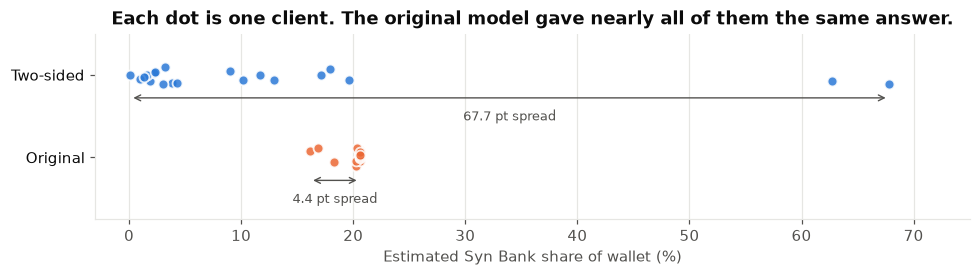

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.6))

rng = np.random.default_rng(7)  # jitter only, so overlapping points stay readable
for y, (vals, colour, label) in enumerate([
    (old["share"].values,    ORANGE, "Original model"),
    (wallet["syn_share"].values, BLUE, "Two-sided model"),
]):
    ax.scatter(vals * 100, np.full(len(vals), y) + rng.uniform(-0.11, 0.11, len(vals)),
               s=42, color=colour, alpha=0.85, linewidth=1.2, edgecolor="white", zorder=3, label=label)
    lo, hi = vals.min() * 100, vals.max() * 100
    ax.annotate("", xy=(lo, y - 0.28), xytext=(hi, y - 0.28),
                arrowprops=dict(arrowstyle="<->", color=MUTED, linewidth=0.9))
    ax.text((lo + hi) / 2, y - 0.42, f"{hi - lo:.1f} pt spread",
            ha="center", va="top", fontsize=8.5, color=MUTED)

ax.set_yticks([0, 1]); ax.set_yticklabels(["Original", "Two-sided"], fontsize=10, color=INK)
ax.set_xlabel("Estimated Syn Bank share of wallet (%)")
ax.set_xlim(-3, 75); ax.set_ylim(-0.75, 1.5)
ax.grid(axis="y", visible=False)
ax.set_title("Each dot is one client. The original model gave nearly all of them the same answer.")
plt.tight_layout(); plt.show()

## 7. Share of wallet by client

findfont: Failed to find font weight 600, now using 700.


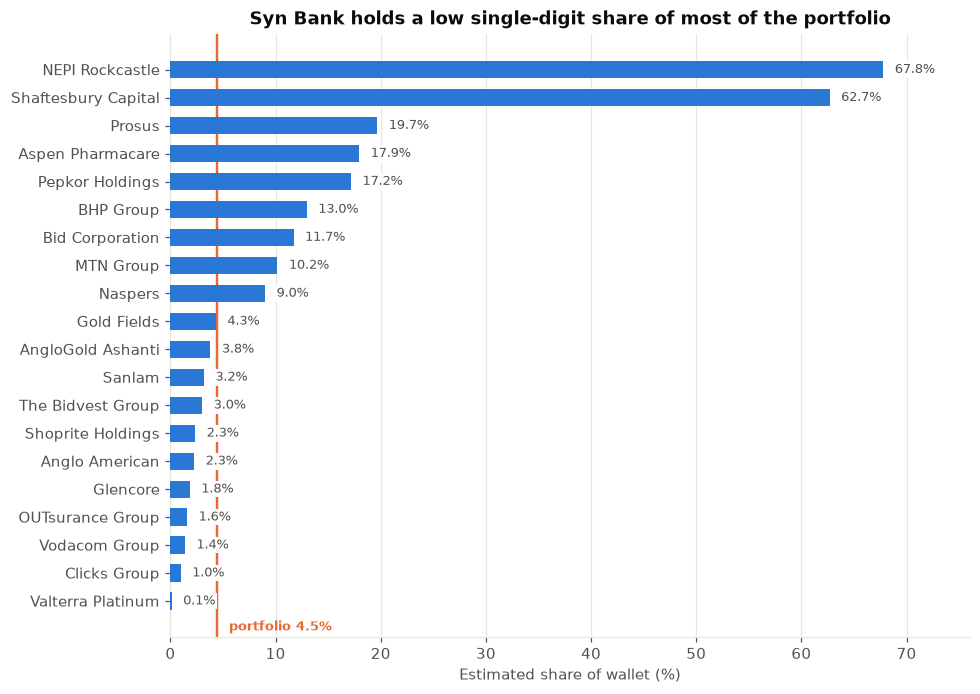

In [10]:
d = wallet.sort_values("syn_share")
fig, ax = plt.subplots(figsize=(9, 6.4))

port = total_capt / total_addr * 100
# Reference line sits behind the marks, and each value label carries a small white
# pad so the low-share labels stay readable where they cross it.
ax.axvline(port, color=ORANGE, linewidth=1.6, zorder=2)

bars = ax.barh(d["client_name"], d["syn_share"] * 100, height=0.62,
               color=BLUE, zorder=3)
for bar, v in zip(bars, d["syn_share"] * 100):
    ax.text(v + 1.1, bar.get_y() + bar.get_height() / 2, f"{v:.1f}%",
            va="center", fontsize=8.5, color=MUTED, zorder=4,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.2))

ax.text(port + 1.1, -1.05, f"portfolio {port:.1f}%", color=ORANGE,
        fontsize=8.5, fontweight="600", zorder=4)

ax.set_xlabel("Estimated share of wallet (%)")
ax.set_xlim(0, 76)
ax.grid(axis="y", visible=False)
ax.set_title("Syn Bank holds a low single-digit share of most of the portfolio")
plt.tight_layout(); plt.show()

The two property names sit far higher than everyone else because almost none of their
activity is addressable to a South African bank — a small denominator, not a strong
relationship. It is a good illustration of why the SA-attribution input deserves
scrutiny.

## 8. Where the money is

Ranking on gap alone points at the biggest client every time. The composite score
blends upside with whether the business is realistically winnable.

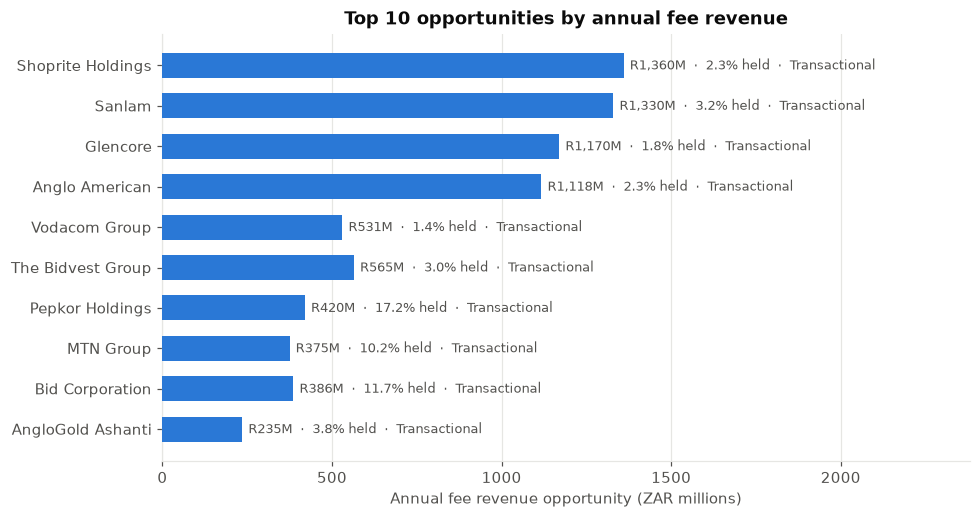

In [11]:
from models.opportunity_engine import score_opportunities

scored = score_opportunities(wallet)
top = scored.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(top["client_name"], top["revenue_opportunity"] / 1e6, height=0.62,
               color=BLUE, zorder=3)
for bar, row in zip(bars, top.itertuples()):
    ax.text(row.revenue_opportunity / 1e6 + 18, bar.get_y() + bar.get_height() / 2,
            f"R{row.revenue_opportunity/1e6:,.0f}M  ·  {row.syn_share*100:.1f}% held  ·  {row.top_pillar}",
            va="center", fontsize=8.5, color=MUTED)

ax.set_xlabel("Annual fee revenue opportunity (ZAR millions)")
ax.set_xlim(0, top["revenue_opportunity"].max() / 1e6 * 1.75)
ax.grid(axis="y", visible=False)
ax.set_title("Top 10 opportunities by annual fee revenue")
plt.tight_layout(); plt.show()

In [12]:
cols = ["rank", "client_name", "sector_display", "syn_share",
        "revenue_opportunity", "top_pillar", "urgency", "confidence"]
t = scored[cols].head(10).copy()
t["syn_share"] = (t["syn_share"] * 100).round(1).astype(str) + "%"
t["confidence"] = (t["confidence"] * 100).round(0).astype(int).astype(str) + "%"
t["revenue_opportunity"] = t["revenue_opportunity"].map(zar)
t.columns = ["rank", "client", "sector", "share", "fee opportunity", "lead pillar", "urgency", "confidence"]
t.set_index("rank")

,client,sector,share,fee opportunity,lead pillar,urgency,confidence
rank,,,,,,,
1,Shoprite Holdings,Consumer Goods,2.3%,R1B,Transactional,Medium,80%
2,Sanlam,Insurance,3.2%,R1B,Transactional,Medium,80%
3,Glencore,Mining,1.8%,R1B,Transactional,Low,80%
4,Anglo American,Mining,2.3%,R1B,Transactional,Low,80%
5,Vodacom Group,Telecoms,1.4%,R531M,Transactional,Medium,80%
6,The Bidvest Group,Industrials & Pharma,3.0%,R565M,Transactional,Low,80%
7,Pepkor Holdings,Consumer Goods,17.2%,R420M,Transactional,Low,95%
8,MTN Group,Telecoms,10.2%,R375M,Transactional,Low,80%
9,Bid Corporation,Consumer Goods,11.7%,R386M,Transactional,Low,80%


## 9. How much do the assumptions drive the answer?

Every flow multiple is shifted together and the portfolio re-estimated. The captured
side cannot move — it is measured — so this isolates the assumption risk.

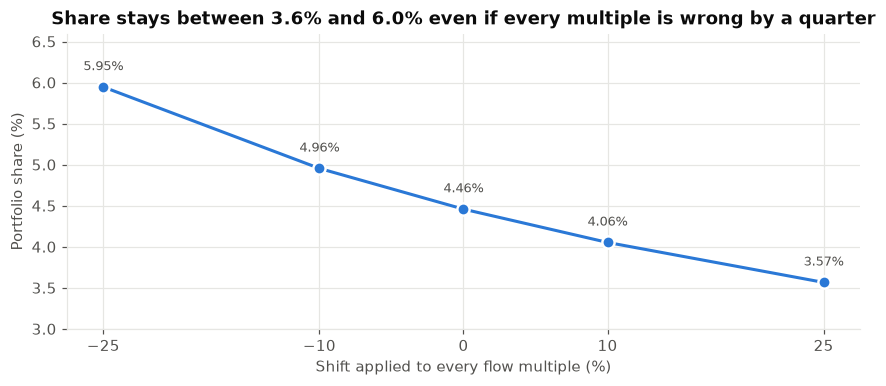

,shift,addressable,captured,share,gap,fee opportunity
0,-25%,R3.2T,R192B,5.95%,R3.0T,R7B
1,-10%,R3.9T,R192B,4.96%,R3.7T,R9B
2,+0%,R4.3T,R192B,4.46%,R4.1T,R10B
3,+10%,R4.7T,R192B,4.06%,R4.5T,R11B
4,+25%,R5.4T,R192B,3.57%,R5.2T,R12B


In [13]:
from models.wallet_engine import sensitivity_analysis

sens = sensitivity_analysis(external, captured, benchmarks=benchmarks)

fig, ax = plt.subplots(figsize=(8, 3.6))
x = sens["multiplier_shift"] * 100
ax.plot(x, sens["portfolio_share"] * 100, color=BLUE, linewidth=2,
        marker="o", markersize=8, markeredgecolor="white", markeredgewidth=1.6, zorder=3)
for xv, yv in zip(x, sens["portfolio_share"] * 100):
    ax.annotate(f"{yv:.2f}%", (xv, yv), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=8.5, color=MUTED)

ax.set_xlabel("Shift applied to every flow multiple (%)")
ax.set_ylabel("Portfolio share (%)")
ax.set_xticks(x); ax.set_ylim(3.0, 6.6)
ax.set_title("Share stays between 3.6% and 6.0% even if every multiple is wrong by a quarter")
plt.tight_layout(); plt.show()

s = sens.copy()
s["multiplier_shift"] = (s["multiplier_shift"] * 100).map(lambda v: f"{v:+.0f}%")
s["portfolio_share"] = (s["portfolio_share"] * 100).round(2).astype(str) + "%"
for c in ["portfolio_addressable", "portfolio_captured", "portfolio_gap", "revenue_opportunity"]:
    s[c] = s[c].map(zar)
s.columns = ["shift", "addressable", "captured", "share", "gap", "fee opportunity"]
s

The captured column is identical on every row. That is the check that the two sides
are genuinely independent — if it moved, the model would still be circular.

The headline conclusion, that Syn Bank holds a low single-digit share and the runway
is large, survives the whole range. Client *rankings* are more stable still, because a
uniform shift moves every client in the same direction.

## 10. Where the gap sits, by pillar and sector

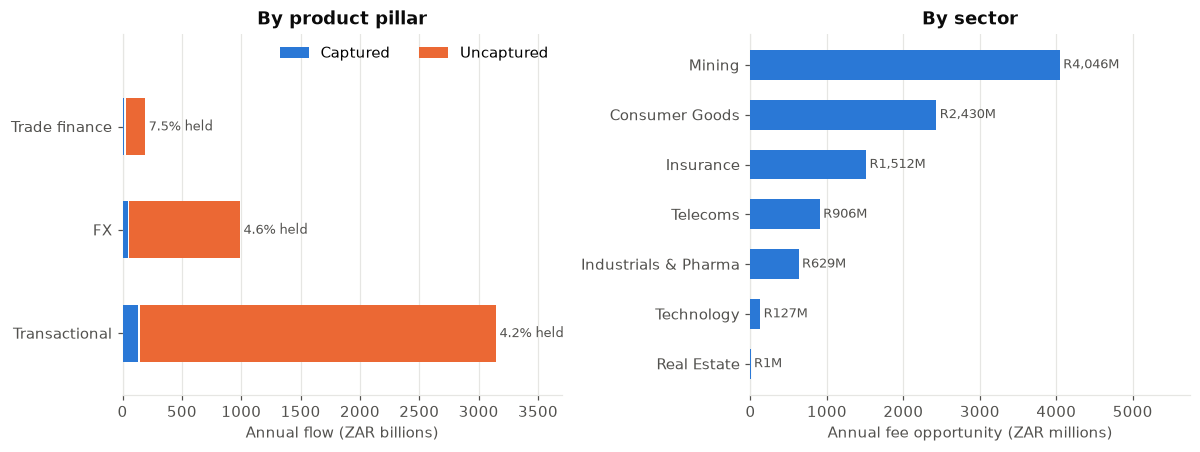

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

pillars = ["Transactional", "FX", "Trade finance"]
capt = [wallet["captured_transactional"].sum(), wallet["captured_fx"].sum(),
        wallet["captured_trade_finance"].sum()]
gap  = [wallet["gap_transactional"].sum(), wallet["gap_fx"].sum(),
        wallet["gap_trade_finance"].sum()]

y = np.arange(3)
ax1.barh(y, np.array(capt) / 1e9, height=0.55, color=BLUE, label="Captured", zorder=3)
ax1.barh(y, np.array(gap) / 1e9, height=0.55, left=np.array(capt) / 1e9 + 12,
         color=ORANGE, label="Uncaptured", zorder=3)   # 2px-equivalent surface gap
for i, (c, g) in enumerate(zip(capt, gap)):
    ax1.text((c + g) / 1e9 + 40, i, f"{c/(c+g)*100:.1f}% held", va="center",
             fontsize=8.5, color=MUTED)
ax1.set_yticks(y); ax1.set_yticklabels(pillars)
ax1.set_xlabel("Annual flow (ZAR billions)")
ax1.set_xlim(0, 3700)
ax1.set_ylim(-0.6, 2.9)          # headroom so the legend clears the top bar
ax1.grid(axis="y", visible=False)
ax1.legend(loc="upper right", ncol=2)
ax1.set_title("By product pillar")

sec = (wallet.groupby("sector_display")
       .agg(gap=("gap", "sum"), oppty=("revenue_opportunity", "sum"))
       .sort_values("oppty"))
bars = ax2.barh(sec.index, sec["oppty"] / 1e6, height=0.6, color=BLUE, zorder=3)
for bar, v in zip(bars, sec["oppty"] / 1e6):
    ax2.text(v + 45, bar.get_y() + bar.get_height() / 2, f"R{v:,.0f}M",
             va="center", fontsize=8.5, color=MUTED)
ax2.set_xlabel("Annual fee opportunity (ZAR millions)")
ax2.set_xlim(0, sec["oppty"].max() / 1e6 * 1.42)
ax2.grid(axis="y", visible=False)
ax2.set_title("By sector")

plt.tight_layout(); plt.show()

## 11. The GenAI layer

The model never supplies a number. Figures are computed here, passed in as an evidence
block, and the model is instructed to reuse them verbatim — it is doing language, not
arithmetic. `verify_grounding` then re-reads the output and flags any rand amount or
percentage that did not appear in the evidence.

Responses are cached to `prompts/cache/`, so this cell runs with no API key and no
network once the cache is present.

In [15]:
from ai import llm
from ai.briefing import generate_briefing

print("provider status:", llm.provider_status(), "\n")

b = generate_briefing("E09")
print(f"generated by : {b['generatedBy']}"
      f"{'  (from cache)' if b.get('cached') else ''}")
print(f"grounding    : {b.get('groundingWarnings') or 'no unsupported figures found'}\n")
print(b["summary"], "\n")
print("Key signals")
for s in b["keySignals"]:
    print(" -", s)
print("\nRecommended agenda")
for a in b["recommendedAgenda"]:
    print(" -", a)
if b.get("risk"):
    print("\nRisk:", b["risk"])

provider status: {'provider': 'gemini', 'model': 'gemini-3.1-flash-lite', 'live': True, 'cachedResponses': 0, 'cachedOnDisk': 5} 



generated by : gemini:gemini-3.1-flash-lite  (from cache)
grounding    : no unsupported figures found

Syn Bank currently captures R15.56B of Shoprite’s estimated R663.23B addressable flow, representing an estimated 2.3% share of wallet. The primary opportunity is to aggressively target the R576.69B transactional gap to unlock an estimated R1.36B in annual fee revenue. 

Key signals
 - Transactional flow has increased by 43.7% over the last 90 days.
 - The client currently processes 203,157 transactional items and 15,867 cross-border payments.
 - Transactional services represent the largest uncaptured gap at R576.69B.

Recommended agenda
 - Propose an integrated liquidity management solution to capture a larger portion of the R576.69B transactional gap.
 - Discuss the 43.7% growth in transactional activity to identify specific operational pain points.
 - Review the R39.10B trade finance gap to align our instruments with their current volume of 2,110 trade items.

Risk: The 23.0% declin

In [16]:
# The guard, demonstrated on a deliberately wrong answer.
facts = "Estimated share of wallet: 2.3%\nUncaptured flow gap: R647.67B"
bad = "Syn Bank holds 23% of this client and can win R99.9B next year."
print("evidence :", facts.replace("\n", " | "))
print("output   :", bad)
print("flagged  :", llm.verify_grounding(bad, facts))

evidence : Estimated share of wallet: 2.3% | Uncaptured flow gap: R647.67B
output   : Syn Bank holds 23% of this client and can win R99.9B next year.
flagged  : ['23%', 'R99.9B']


## 12. Findings

1. **Syn Bank holds an estimated 4.5% of its clients' addressable banking flow** —
   R191.6bn of R4.29tn — worth **R9.65bn a year in fee revenue** if fully closed.
2. **Transactional banking is the dominant gap**, and it is the lead pillar for
   19 of the 20 clients. Cash management consolidation is the repeatable
   conversation across the whole book.
3. **Share is not uniform.** It runs from 0.1% to 67.8%. Pepkor and Aspen sit near
   17–18% while Shoprite, a much larger company, sits at 2.3% — Syn Bank is
   over-indexed on some relationships and barely present in others of similar size.
4. **The conclusion is robust.** Under a +/-25% shift in every assumption, portfolio
   share stays between 3.6% and 6.0%.

### Sanity check against the brief

Our multiples imply total banking fees of roughly **0.47% of revenue** for
transactional banking, which sits inside the **0.4–0.7%** range the brief itself
cites. That is an independent check on parameters we set from a different direction.

## 13. Limitations

1. **20 clients, not 50.** We modelled the data supplied.
2. **Multiples are benchmarks, not observations.** Section 9 quantifies the exposure.
3. **SA attribution is judgmental** and is the input we would most want to replace
   with disclosed segment data.
4. **Revenue basis differs by industry** — IFRS 17 insurance revenue for insurers,
   rental income for the property companies, marketing turnover for Glencore
   (which is why its SA-attribution is set very low). Each basis is recorded per
   client. No estimated revenues remain: all 20 are reported or derived.
5. **Imputed cost of sales and inventory** where not separately disclosed, flagged
   per client.
6. **Gaps are attributed to competitors.** Some uncaptured flow is self-funded,
   netted internally, or simply does not exist.
7. **Lending and DCM are out of scope** — the supplied data covers three pillars.

Full methodology, including the citation for every external figure:
[`docs/methodology.md`](../docs/methodology.md).